# Convolutional Neural Networks for Facial Emotion Classification

**Mariana Malagón Tochoy**

In this notebook I explore convolutional layers as an architectural component for image classification, using the FER2013 facial emotion dataset. My goal isn't to reach the highest possible accuracy, but to understand and justify the architectural decisions behind a convolutional model, and to compare it against a non-convolutional baseline.

## Why FER2013 Fits a Convolutional Approach

I picked FER2013 because what actually separates one emotion from another isn't the whole image, it's a handful of local features: the shape and position of the eyebrows, how open the eyes are, the shape of the mouth. The background and the rest of the face barely matter for telling emotions apart.

Those features don't sit in the same pixels across images. Every photo is a different person at a slightly different angle and position, so a pattern like "furrowed eyebrows" can show up in a different spot from one image to the next. A dense network has to learn that pattern separately for every position it could appear in, which with a dataset this size is asking a lot. A convolutional kernel learns the pattern once and can detect it anywhere in the image, since the same weights slide across the whole picture. That translational invariance is exactly what this dataset needs, since the emotion-relevant features move around from photo to photo but the patterns themselves stay the same.

## Learning Objectives

By the end of this notebook, I should be able to:

- Explore and describe the structure of an image dataset (size, class distribution, dimensions, channels).
- Explain the role and mathematical intuition behind convolutional layers.
- Build a non-convolutional baseline (Flatten + Dense) as a reference point.
- Design a convolutional architecture from scratch and justify each choice (kernel size, stride, padding, depth, pooling).
- Run a controlled experiment on one aspect of the convolutional layer and interpret the results.
- Reason about the inductive bias convolution introduces, and when it is (or isn't) appropriate.

## 0. Setup

In [1]:
# Run this cell only if the required packages are not installed in your environment.
# Installing tensorflow on its own lets pip resolve its numpy version quickly,
# instead of backtracking over every package at once.
# After installation, restart the kernel and continue with the next cells.

%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# These are lightweight and install quickly on their own.
%pip install matplotlib pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# NumPy handles arrays and vectorized numerical operations.
import numpy as np

# Matplotlib is used to visualize images, class distributions, and training curves.
import matplotlib.pyplot as plt

# PIL lets us inspect individual image files before loading the full dataset.
from PIL import Image

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
    TF_AVAILABLE = True
    print("TensorFlow version:", tf.__version__)
except Exception as exc:
    TF_AVAILABLE = False
    print("TensorFlow is not available:", exc)

TensorFlow version: 2.21.0


## 1. Dataset Exploration (EDA)

### 1.1 A first look at a single image

Before loading the full dataset, i´m going to inspect one sample image to see its dimensions and color mode.

In [4]:
img = Image.open("data/train/happy/Training_1206.jpg")
print(img.size, img.mode)

(48, 48) L


### 1.2 Class distribution and format consistency

Before I build any model I need to check two things: whether every image in the dataset actually matches the format I found in the single sample above (48x48, grayscale, not just that one file), and how many images each emotion class has in train and test.

Both checks need me to go through every file once, so instead of scanning the dataset twice I do both things in the same pass below: while I count how many files each class has, I also open every image to check its size and color mode.

In [5]:
import os

DATA_DIR = "data"
SPLITS = ["train", "test"]

# Counts per class, per split. This is the class distribution part of the EDA.
class_counts = {split: {} for split in SPLITS}

# Every unique (width, height) and color mode I find across the dataset.
# If each set ends up with only one value, I don't need to resize images
# or change channels before building the model's input arrays.
sizes_found = set()
modes_found = set()

for split in SPLITS:
    split_dir = os.path.join(DATA_DIR, split)
    for class_name in sorted(os.listdir(split_dir)):
        class_dir = os.path.join(split_dir, class_name)
        filenames = os.listdir(class_dir)
        class_counts[split][class_name] = len(filenames)

        for filename in filenames:
            with Image.open(os.path.join(class_dir, filename)) as img:
                sizes_found.add(img.size)
                modes_found.add(img.mode)

print("Unique image sizes found across the whole dataset:", sizes_found)
print("Unique image color modes found across the whole dataset:", modes_found)

Unique image sizes found across the whole dataset: {(48, 48)}
Unique image color modes found across the whole dataset: {'L'}


A table is precise but slow to compare. A bar chart makes the imbalance across classes obvious at a glance. I'm plotting train and test side by side because a dataset can look balanced in one split and skewed in the other, so showing both catches that.

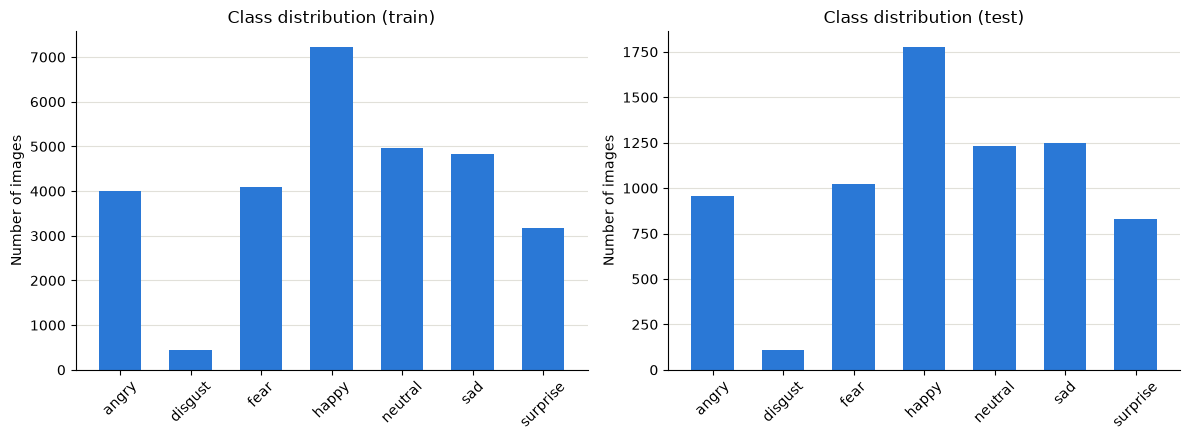

In [6]:
# I use one color for every bar because there is only one series here (image count).
# Color isn't encoding class identity, the x-axis position already does that.
BAR_COLOR = "#2a78d6"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, split in zip(axes, SPLITS):
    class_names = list(class_counts[split].keys())
    counts = list(class_counts[split].values())

    ax.bar(class_names, counts, color=BAR_COLOR, width=0.6)
    ax.set_title(f"Class distribution ({split})")
    ax.set_ylabel("Number of images")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### 1.3 Examples per class

The counts tell me how many images each class has, but not what actually distinguishes them. I'm looking at a few random samples from each class to get a feel for how clear (or subtle) the difference between emotions looks in practice.

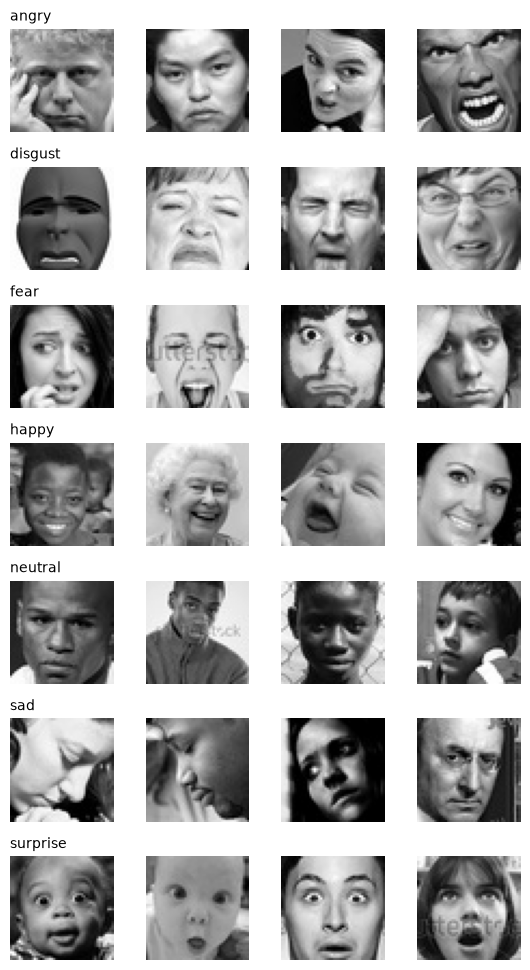

In [7]:
import random

random.seed(7)
N_SAMPLES = 4
class_names = list(class_counts["train"].keys())

fig, axes = plt.subplots(len(class_names), N_SAMPLES, figsize=(N_SAMPLES * 1.4, len(class_names) * 1.4))

for row, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, "train", class_name)
    filenames = random.sample(os.listdir(class_dir), N_SAMPLES)

    for col, filename in enumerate(filenames):
        img = Image.open(os.path.join(class_dir, filename))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(class_name, loc="left", fontsize=10)

plt.tight_layout()
plt.show()

### 1.4 Preprocessing I'll need

From everything above I already know two things don't need fixing: every image is 48x48, so no resizing, and every image is single channel grayscale, so no color conversion.

What I still need to check is the actual pixel value range, since that decides whether I need to normalize before training.

In [8]:
sample_array = np.array(Image.open("data/train/happy/Training_1206.jpg"))
print("dtype:", sample_array.dtype)
print("shape:", sample_array.shape)
print("min pixel value:", sample_array.min())
print("max pixel value:", sample_array.max())

dtype: uint8
shape: (48, 48)
min pixel value: 13
max pixel value: 237


Pixel values come as `uint8` in the 0 to 255 range, which is too large a scale for a network to train on efficiently. Before building any model I'll need to:

- Divide pixel values by 255.0 so they fall between 0 and 1.
- Reshape each image from `(48, 48)` to `(48, 48, 1)`, since `Conv2D` expects an explicit channel dimension even when there's only one channel.

No resizing and no color conversion needed, since those are already consistent across the whole dataset.

## 2. Baseline Model (Non-Convolutional)

Before I can train anything I need the images as numeric arrays instead of files on disk. I load every image in `train` and `test` into `X_train`/`y_train` and `X_test`/`y_test`, reusing the same `class_names` order from the sample grid above, so the label number always matches the same class.

In [9]:
def load_split(split, class_names):
    images = []
    labels = []

    # enumerate turns each class name into a fixed integer label
    # (angry -> 0, disgust -> 1, ...), which is what the model needs.
    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(DATA_DIR, split, class_name)
        for filename in os.listdir(class_dir):
            img = Image.open(os.path.join(class_dir, filename))
            # Normalize pixels from 0-255 to 0-1, easier for the network to train on.
            images.append(np.array(img, dtype=np.float32) / 255.0)
            labels.append(label)

    # reshape adds the channel dimension Conv2D expects: (num_images, 48, 48, 1).
    X = np.array(images).reshape(-1, 48, 48, 1)
    y = np.array(labels)
    return X, y

X_train, y_train = load_split("train", class_names)
X_test, y_test = load_split("test", class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (28709, 48, 48, 1)
y_train shape: (28709,)
X_test shape: (7178, 48, 48, 1)
y_test shape: (7178,)


`load_split` appends images class by class, so `X_train`/`y_train` are still in that order (all "angry" first, then "disgust", ... "surprise" last). If I train like this, Keras' `validation_split` in `fit` takes the last fraction of the array as validation without shuffling first, which here would land almost entirely on one single class. I need to shuffle `X_train` and `y_train` together, keeping each image paired with its correct label, before training.

In [10]:
# A reproducible random reordering of indices, applied the same way to both
# arrays so each image stays matched with its correct label.
shuffle_idx = np.random.RandomState(7).permutation(len(X_train))
X_train = X_train[shuffle_idx]
y_train = y_train[shuffle_idx]

### 2.1 Architecture

My baseline is the simplest thing that can classify these images: flatten each 48x48x1 image into a single vector, pass it through one hidden layer, and end in an output layer with one neuron per emotion. No convolution, no knowledge of which pixels are near which, just a plain fully connected network.

In [11]:
baseline_model = Sequential([
    Flatten(input_shape=(48, 48, 1)),
    Dense(128, activation="relu"),
    # One output neuron per emotion, softmax turns the 7 scores into probabilities.
    Dense(len(class_names), activation="softmax"),
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()

c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,943 (1.13 MB)

 Trainable params: 295,943 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Training

I'm keeping `X_test`/`y_test` completely untouched during training and only using it for the final evaluation, so I carve out 10% of `X_train` as a validation set instead. That way the test set stays a true holdout, and the validation curves below still show me how the model does on data it wasn't trained on.

In [12]:
history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
)

Epoch 1/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2871 - loss: 1.7801 - val_accuracy: 0.2870 - val_loss: 1.7716
Epoch 2/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3257 - loss: 1.7067 - val_accuracy: 0.3379 - val_loss: 1.6885
Epoch 3/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3423 - loss: 1.6719 - val_accuracy: 0.3581 - val_loss: 1.6753
Epoch 4/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3513 - loss: 1.6619 - val_accuracy: 0.3225 - val_loss: 1.7171
Epoch 5/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3541 - loss: 1.6529 - val_accuracy: 0.3546 - val_loss: 1.6608
Epoch 6/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3580 - loss: 1.6403 - val_accuracy: 0.3595 - val_loss: 1.6690
Epoch 7/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3633 - loss: 1.6276 - val_accuracy: 0.3473 - val_loss: 1.7203
Epoch 8/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3704 - loss: 1.6173 - val_accuracy: 0.

With 7 classes, guessing at random would give about 14% accuracy. This baseline reaches around 36 to 39%, both on train and validation, so it's learning something real, well above chance.

Train and validation accuracy climb together and stay close to each other the whole time (they don't split apart), so there's no overfitting yet in these 15 epochs, the model just hasn't had time to memorize anything. Both curves are still creeping up slowly by the last epoch, which suggests a bit more training could help a little, but a Flatten + Dense architecture has a low ceiling for a problem like this one.

### 2.3 Training and validation performance

The printed numbers above are hard to compare epoch by epoch, so I plot the loss and accuracy curves instead. Then I evaluate on `X_test`/`y_test`, the split I kept completely out of training, for the final number I'll report.

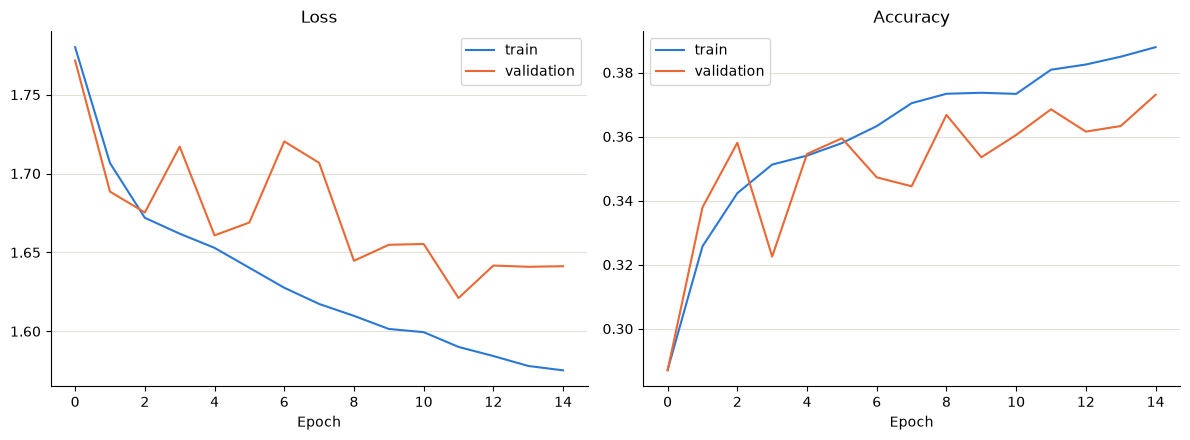

In [13]:
# train in blue, validation in orange, same two colors everywhere I compare the two.
TRAIN_COLOR = "#2a78d6"
VAL_COLOR = "#eb6834"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["loss"], color=TRAIN_COLOR, label="train")
axes[0].plot(history.history["val_loss"], color=VAL_COLOR, label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], color=TRAIN_COLOR, label="train")
axes[1].plot(history.history["val_accuracy"], color=VAL_COLOR, label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

for ax in axes:
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
test_loss, test_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 1.6001323461532593
Test accuracy: 0.38673725724220276


### Observed limitations

This baseline tops out around 37% test accuracy. That's well above the 14% a random guess would get with 7 classes, but nowhere close to reliable. It doesn't even hold onto that ceiling cleanly: from about epoch 10 onward, training accuracy keeps climbing while validation accuracy plateaus and then drops, which is overfitting. The model has 295,943 parameters and no built-in notion that nearby pixels are related, so once it runs out of genuinely useful patterns to pull from the flattened pixel vector, it starts fitting to noise specific to the training images instead of features that generalize.

I'd also expect this baseline to struggle disproportionately on "disgust", the class with by far the fewest training examples (436, versus over 7,000 for "happy"). I haven't measured per-class accuracy yet, but between that imbalance and the lack of any architectural bias toward the local features that actually distinguish these expressions, that's a reasonable place for it to fail hardest.

## 3. Convolutional Architecture Design

I'm keeping this CNN simple but intentional, not deep for its own sake. Every choice below is something I picked and can justify, not copied from a tutorial.

**Number of convolutional layers**: two blocks (Conv2D + MaxPooling2D each). With 48x48 images and a dataset this size, two blocks is enough to go from simple edge-like patterns in the first layer to more complex combinations in the second, without adding so many parameters that overfitting gets even worse than what I already saw in the baseline.

**Kernel sizes**: 3x3 in both blocks. Small enough to focus on local features, like the corner of an eye or the curve of an eyebrow, without wasting parameters on a receptive field bigger than what those features need.

**Number of filters**: 32 in the first block, 64 in the second. Fewer filters early on because the first layer only needs to catch simple patterns, more filters later because the second layer has to combine those into a wider variety of more complex ones.

**Stride and padding**: stride of 1 in both convolutions, `padding="same"` in both. I'm using MaxPooling to downsample, not stride, so the convolutions themselves scan every position. `same` padding keeps the output the same size as the input at each conv step, so pixels near the edge of the face (chin, ears) get seen by the kernel as much as pixels near the center.

**Activation functions**: `relu` after every convolution, same reason as the baseline: it adds the non-linearity that keeps stacked layers from collapsing into a single linear operation.

**Pooling strategy**: `MaxPooling2D(2, 2)` after every convolutional block. It halves the spatial size each time (48 -> 24 -> 12), which keeps the parameter count under control going into the dense layers, and gives some tolerance for a feature not landing on the exact same pixel in every image.

**Dense head**: after the two convolutional blocks I flatten and reuse the exact same `Dense(128, relu) -> Dense(7, softmax)` head from the baseline. Keeping the dense part identical means any accuracy difference between this model and the baseline can be attributed to the convolutional layers, not to a different classifier on top.

In [15]:
cnn_model = Sequential([
    # Block 1: catches simple, local patterns (edges, contrast blobs).
    Conv2D(32, kernel_size=3, padding="same", activation="relu", input_shape=(48, 48, 1)),
    MaxPooling2D(2),

    # Block 2: more filters to combine block 1's patterns into more complex ones.
    Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    MaxPooling2D(2),

    # Same dense head as the baseline, on purpose, see markdown above.
    Flatten(),
    Dense(128, activation="relu"),
    Dense(len(class_names), activation="softmax"),
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_model.summary()

c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Controlled Experiment: With vs Without Pooling

I'm testing one aspect of the convolutional layer: whether `MaxPooling2D` after each conv block helps or not. Everything else stays fixed between the two variants: same 2 conv blocks (32 then 64 filters, 3x3 kernel, `same` padding, `relu`), same dense head, same training settings (15 epochs, batch size 64, same 10% validation split). The only difference is pooling present vs absent.

**Variant A, with pooling**: this is the `cnn_model` I already built in section 3. I train it now.

In [16]:
history_pooling = cnn_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
)

test_loss_pooling, test_accuracy_pooling = cnn_model.evaluate(X_test, y_test, verbose=0)
print("Test loss (with pooling):", test_loss_pooling)
print("Test accuracy (with pooling):", test_accuracy_pooling)

Epoch 1/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.3589 - loss: 1.6341 - val_accuracy: 0.4284 - val_loss: 1.5087
Epoch 2/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.4582 - loss: 1.4168 - val_accuracy: 0.4608 - val_loss: 1.4258
Epoch 3/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.5016 - loss: 1.3050 - val_accuracy: 0.4963 - val_loss: 1.3513
Epoch 4/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.5417 - loss: 1.2111 - val_accuracy: 0.5009 - val_loss: 1.3238
Epoch 5/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.5820 - loss: 1.1165 - val_accuracy: 0.5068 - val_loss: 1.3094
Epoch 6/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.6257 - loss: 1.0129 - val_accuracy: 0.5263 - val_loss: 1.3060
Epoch 7/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.6686 - loss: 0.9033 - val_accuracy: 0.5249 - val_loss: 1.3678
Epoch 8/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.7175 - loss: 0.7884 - 

**Variant B, without pooling**: identical to `cnn_model`, just removing both `MaxPooling2D` layers. Without them, the spatial size never shrinks inside the conv blocks, it stays 48x48 all the way to `Flatten`, so I expect a much bigger `Flatten` output (48x48x64 instead of 12x12x64) and a much heavier first dense layer.

In [17]:
cnn_model_no_pooling = Sequential([
    Conv2D(32, kernel_size=3, padding="same", activation="relu", input_shape=(48, 48, 1)),
    Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(len(class_names), activation="softmax"),
])

cnn_model_no_pooling.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_model_no_pooling.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    18,874,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,894,215 (72.08 MB)

 Trainable params: 18,894,215 (72.08 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_no_pooling = cnn_model_no_pooling.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
)

test_loss_no_pooling, test_accuracy_no_pooling = cnn_model_no_pooling.evaluate(X_test, y_test, verbose=0)
print("Test loss (no pooling):", test_loss_no_pooling)
print("Test accuracy (no pooling):", test_accuracy_no_pooling)

Epoch 1/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 139s 338ms/step - accuracy: 0.3363 - loss: 1.7097 - val_accuracy: 0.4169 - val_loss: 1.5409
Epoch 2/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 132s 327ms/step - accuracy: 0.4597 - loss: 1.4154 - val_accuracy: 0.4573 - val_loss: 1.4298
Epoch 3/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 132s 326ms/step - accuracy: 0.5582 - loss: 1.1808 - val_accuracy: 0.4768 - val_loss: 1.4330
Epoch 4/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 135s 333ms/step - accuracy: 0.6815 - loss: 0.8726 - val_accuracy: 0.4660 - val_loss: 1.5793
Epoch 5/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 141s 350ms/step - accuracy: 0.8266 - loss: 0.5059 - val_accuracy: 0.4727 - val_loss: 1.8793
Epoch 6/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 141s 349ms/step - accuracy: 0.9332 - loss: 0.2275 - val_accuracy: 0.4667 - val_loss: 2.5441
Epoch 7/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 142s 349ms/step - accuracy: 0.9804 - loss: 0.0897 - val_accuracy: 0.4660 - val_loss: 3.0877
Epoch 8/15
404/404 ━━━━━━━━━━━━━━━━━━━━ 141s 349ms/step - accuracy: 0.9911 -

### 4.1 Comparing the two variants

I compare validation curves (not train) between the two variants, since validation is what tells me how each one actually generalizes, not just how well it memorizes. I also print the parameter count and final test accuracy for both, side by side.

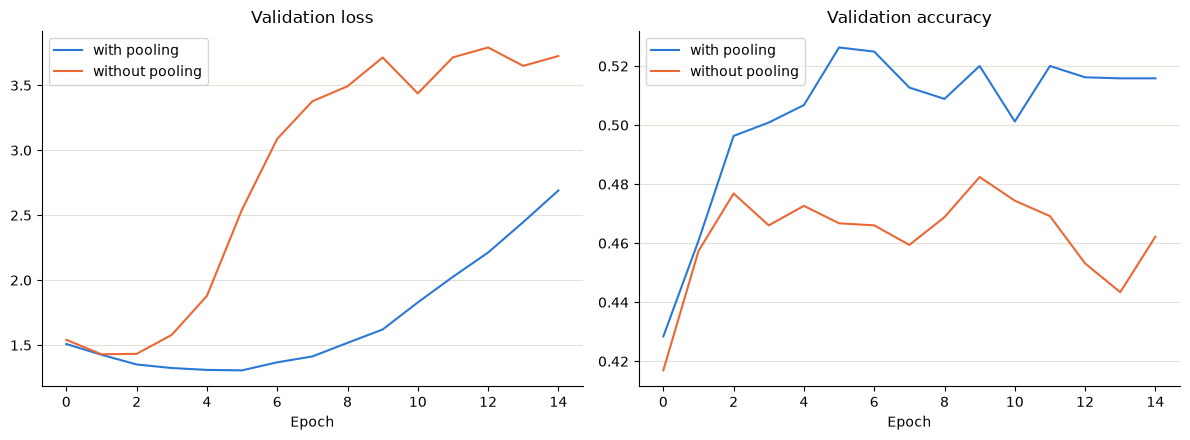

With pooling:    1,199,495 params, test accuracy 0.5187
Without pooling: 18,894,215 params, test accuracy 0.4660


In [19]:
POOLING_COLOR = "#2a78d6"
NO_POOLING_COLOR = "#eb6834"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_pooling.history["val_loss"], color=POOLING_COLOR, label="with pooling")
axes[0].plot(history_no_pooling.history["val_loss"], color=NO_POOLING_COLOR, label="without pooling")
axes[0].set_title("Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_pooling.history["val_accuracy"], color=POOLING_COLOR, label="with pooling")
axes[1].plot(history_no_pooling.history["val_accuracy"], color=NO_POOLING_COLOR, label="without pooling")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

for ax in axes:
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print(f"With pooling:    {cnn_model.count_params():,} params, test accuracy {test_accuracy_pooling:.4f}")
print(f"Without pooling: {cnn_model_no_pooling.count_params():,} params, test accuracy {test_accuracy_no_pooling:.4f}")

### 4.2 Results and trade-offs

Removing pooling made the model 15.7 times heavier (18,894,215 vs 1,199,495 parameters) and about 5 times slower per epoch (130-140s vs 25-28s), and it still did worse: 46.60% test accuracy without pooling versus 51.87% with it.

The validation curves explain why. Without pooling, validation loss shoots up almost immediately and keeps climbing past 3.7 by the last epoch, while training accuracy rockets to 93%, then 98%, then 99% within the first 7 epochs. That's the model memorizing training images instead of learning patterns that generalize. Pooling holds that off: validation loss stays much lower and rises more slowly, because pooling throws away the exact position of each activation (it only keeps the strongest value in each 2x2 block) and shrinks the dense layer that follows from 18.9 million parameters down to 1.2 million. With less spatial detail and far fewer places to store information, the model has less room to memorize training-specific noise, so it's pushed toward learning patterns that actually hold up on unseen images.

The trade-off here isn't close: pooling costs nothing in complexity, it removes parameters, and it wins on every axis I measured, accuracy, training time, and model size. For this dataset and this depth of network, pooling isn't optional overhead, it's doing real work.

## 5. Interpretation and Architectural Reasoning

### Why did convolutional layers outperform the baseline?

The numbers back it up directly: the baseline reached 38.29% test accuracy, the CNN with pooling reached 51.87%, almost 14 percentage points higher, while using roughly 4 times fewer parameters than the baseline needed to reach its lower number.

This lines up exactly with the argument I made when picking this dataset. What separates one emotion from another in FER2013 is a handful of local features (the shape of the eyebrows, how open the eyes are, the curve of the mouth), and those features don't sit in the same pixels across images, since every face is a different person at a slightly different angle and position. The baseline's dense layer connects every input pixel to every hidden neuron with its own independent weight, so if it only ever saw "furrowed eyebrows" in one region of the image during training, it has no way to recognize that same pattern showing up a few pixels over in a photo it hasn't seen. It would have to relearn the pattern separately for every position it could appear in, and with about 29,000 training images spread across 7 classes (some as small as 436 examples), there isn't enough data for that. The CNN's filters are reused across every position in the image, so once a filter learns to detect a pattern like a curved eyebrow edge, it can find that same pattern anywhere, without needing a separate example for every possible position. That's a direct match between the architecture and the actual structure of this data, and the accuracy gap is the measurable result of that match.

### What inductive bias does convolution introduce?

An inductive bias is an assumption a model is built with before it ever sees data, one that narrows down what it's able to learn efficiently. Convolution bakes in three of them:

- **Locality**: it assumes that pixels near each other are more related than pixels far apart, so each filter only ever looks at a small neighborhood at a time (a 3x3 patch, in my case) instead of the whole image at once.
- **Translation invariance, through parameter sharing**: the same filter weights are reused at every position in the image, so a pattern means the same thing no matter where it shows up. This is the assumption that let my CNN recognize a raised eyebrow whether it appeared near the top-left or the center of a face.
- **Hierarchical composition**: stacking convolutional layers assumes complex patterns are built out of simpler ones, edges combine into curves, curves combine into the shape of an eye or a mouth. That's why depth matters, and why my second block used more filters than the first, to combine the simple patterns the first block found into more complex ones.

None of these assumptions are learned from the data, they're built into the architecture itself. That's what makes them an inductive bias rather than a conclusion: they're a bet, made before training even starts, about what kind of patterns are worth looking for.

### When would convolution not be appropriate?

Convolution is a good bet only when its assumptions actually hold. It would be a poor fit for:

- **Tabular data without spatial structure**, like a table of age, income, and zip code. There's no meaningful sense in which "income" is a neighbor of "age", shuffling the columns doesn't change what the data means the way shuffling the pixels of an image would. Locality and parameter sharing don't have anything to attach to, so a Dense layer that can freely weigh each feature on its own is the more natural fit.
- **Problems where position itself carries meaning that shouldn't be shared**, the opposite situation from FER2013. If the same value appearing in two different positions should be treated as two completely different things, translation invariance actively works against the model, since it's specifically designed to treat the same pattern the same way everywhere.
- **Problems that depend on long-range relationships between distant parts of the input** more than on local patterns. Convolution has to stack many layers before its receptive field grows large enough to relate far-apart regions, which is part of why architectures built around attention, rather than locality, tend to do better on tasks like long-document language understanding, where the important connection might be between the first and the last sentence.

My own controlled experiment in section 4 is a small version of this same idea: even inside a convolutional architecture, removing pooling, a piece that encodes locality more aggressively by discarding exact position, didn't just cost more compute, it made the model worse, because the extra capacity went into memorizing training images instead of learning patterns that generalize. Matching the architecture's assumptions to the actual structure of the data isn't a minor detail, it's most of what made the difference in this notebook.